# Session 7: Linear Regression


SHAFE:JAWAD
LEARNING GOALS

1. Understand what linear regression does and when to use it for prediction problems
2. Learn how the cost function measures how wrong our predictions are
3. Implement gradient descent from scratch to find optimal weights and bias
4. Know how the learning rate affects whether training converges or diverges
5. Compute partial derivatives of the cost function with respect to each parameter

<a name="1"></a>
## 1 - Packages

First, let's run the cell below to import all the packages that you will need during this assignment.
- [numpy](www.numpy.org) is the fundamental package for working with matrices in Python.
- [matplotlib](http://matplotlib.org) is a famous library to plot graphs in Python.
- ``utils.py`` contains helper functions for this assignment. You do not need to modify code in this file.


SHAFE:JAWAD

Here we import the packages we need for linear regression.
1. numpy is our main math library, it lets us work with arrays and do matrix operations
2. matplotlib.pyplot is for making graphs and visualizations
3. copy is for making deep copies of objects so we dont accidentally modify the original
4. math gives us basic math functions like sqrt and ceil

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
%matplotlib inline

SHAFE:JAWAD

This function loads our housing dataset from Google Drive. It grabs a CSV file with house data, then extracts two things: the house sizes (column 0, divided by 1000 to make numbers smaller and easier to work with) and the prices (column 4). Having smaller numbers helps gradient descent converge faster and avoids numerical overflow issues.

In [2]:
import numpy as np


def load_data():
    data = np.loadtxt("https://drive.google.com/uc?id=1AkapW4GntdONcHy7God30DETeUPfgax6", delimiter=',',skiprows=1)

    X = data[:,0]/1000.0
    y = data[:,4]

    return X, y

In [3]:
import urllib
from urllib.request import urlopen

def feedback(excercise_id, finished=True, understood=True, comment="No comments"):
  base_url = "https://docs.google.com/forms/d/e/"
  base_url += "1FAIpQLSdQwo5EswpUpJnx0cHgPdJzuiUsg7KiJMORmC5VZBSGEhjPrQ"
  base_url += "/formResponse?"
  base_url += "entry.2058183318=" + excercise_id
  base_url += "&entry.217828241=" + ("Yes" if finished else "No")
  base_url += "&entry.676697552=" + ("Yes" if understood else "No")
  base_url += "&entry.379660172=" + comment

  base_url = base_url.replace(" ", "%20")
  urlopen(base_url)
  print("FEEDBACK SUBMITTED. THANKS!!! :D")


## 2 -  Problem Statement

## 2.1 Data Set
We will use the motivating example of housing price prediction. The training data set contains many houses with size and its selling price.

We would like to build a linear regression model using the size we can then predict the price for other houses - say, a house with 1200 sqft

SHAFE:JAWAD

Now we actually call the load_data function. x_train holds our input features (house sizes) and y_train holds our target values (house prices). These are the data points we will use to train our linear regression model.


## 3 - Dataset

You will start by loading the dataset for this task.
- The `load_data()` function shown below loads the data into variables `x_train` and `y_train`
  - `x_train` is the size of the house
  - `y_train` is the value of the house
  - Both `X_train` and `y_train` are numpy arrays.

In [4]:
# load the dataset
x_train, y_train = load_data()

#### View the variables
Before starting on any task, it is useful to get more familiar with your dataset.  
- A good place to start is to just print out each variable and see what it contains.

The code below prints the variable `x_train` and the type of the variable.

In [5]:
# print x_train
print("Type of x_train:",type(x_train))
print("First five elements of x_train are:\n", x_train[:5])

Type of x_train: <class 'numpy.ndarray'>
First five elements of x_train are:
 [1.244 1.947 1.725 1.959 1.314]


In [6]:
# print y_train
print("Type of y_train:",type(y_train))
print("First five elements of y_train are:\n", y_train[:5])

Type of y_train: <class 'numpy.ndarray'>
First five elements of y_train are:
 [300.  509.8 394.  540.  415. ]


#### Check the dimensions of your variables

Another useful way to get familiar with your data is to view its dimensions.

Please print the shape of `x_train` and `y_train` and see how many training examples you have in your dataset.

SHAFE:JAWAD

This scatter plot shows our raw data. Each red X represents one house, with size on the x-axis and price on the y-axis. Looking at this we can see there is a general upward trend, bigger houses tend to cost more. This is WHY linear regression makes sense here, we want to draw a line through these points that captures this relationship.

In [7]:
print ('The shape of x_train is:', x_train.shape)
print ('The shape of y_train is: ', y_train.shape)
print ('Number of training examples (m):', len(x_train))

The shape of x_train is: (99,)
The shape of y_train is:  (99,)
Number of training examples (m): 99


#### Visualize your data



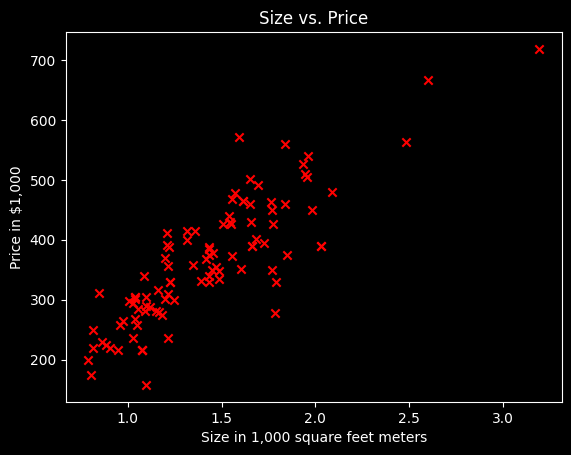

In [8]:
# Create a scatter plot of the data. To change the markers to red "x",
# we used the 'marker' and 'c' parameters
plt.scatter(x_train, y_train, marker='x', c='r')

# Set the title
plt.title("Size vs. Price")
# Set the y-axis label
plt.ylabel('Price in $1,000')
# Set the x-axis label
plt.xlabel('Size in 1,000 square feet meters')
plt.show()

SHAFE:JAWAD

This is the MODEL function, the core of linear regression. For each input x, it computes the prediction f(x) = w*x + b. Here w is the slope (how much price changes per unit of size) and b is the intercept (the base price when size is zero). We loop through each training example and apply this formula. The result is an array of predictions, one for each house in our data.

## 4 Model function

As described in lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$

The formula above is how you can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot. <br/> <br/> <br/>

Now, let's compute the value of $f_{w,b}(x^{(i)})$ for your two data points. You can explicitly write this out for each data point as -

for $x^{(0)}$, `f_wb = w * x[0] + b`

for $x^{(1)}$, `f_wb = w * x[1] + b`



<a name="ex01"></a>
### Exercise 1: Model Predition


SHAFE:JAWAD

Here we test our model with some initial guesses for w and b. We set w=250 and b=0 just to see what the line looks like. These are NOT the optimal values, we are just experimenting. Later gradient descent will find the best values automatically.


Complete the function `compute_model_output` to compute the output of a linear regression model given a vector of $x$ values and a two parameters $w$ and $b$.

> **Note**: The argument description `(ndarray (m,))` describes a Numpy n-dimensional array of shape (m,). `(scalar)` describes an argument without dimensions, just a magnitude.  
> **Note**: `np.zero(n)` will return a one-dimensional numpy array with $n$ entries   


SHAFE:JAWAD

**How to approach this exercise:**

We need to write a function that applies the linear model formula to every training example. For each house size x, compute the prediction f(x) = w*x + b. The steps are:
1. Get the number of examples m from the input shape
2. Create an empty array to store predictions
3. Loop through each example and apply the formula
4. Return the array of predictions

The output should be an array the same size as x with one prediction per house.

In [9]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples
      w,b (scalar)    : model parameters
    Returns
      y (ndarray (m,)): target values
    """

    m = x.shape[0]  # SHAFE:JAWAD get the number of training examples
    f_wb = np.zeros(m)  # SHAFE:JAWAD create empty array to store predictions
    for i in range(m):
        f_wb[i] = x[i]*w + b  # SHAFE:JAWAD apply linear model formula for each example

    return f_wb

Now let's call the `compute_model_output` function and plot the output..



Let's try to get a better intuition for this through the code blocks below. Let's start with $w = 1$ and $b = 4$.

**Note: You can come back to this cell to adjust the model's w and b parameters**

In [10]:
w = 250
b = 0
print(f"w: {w}")
print(f"b: {b}")

w: 250
b: 0


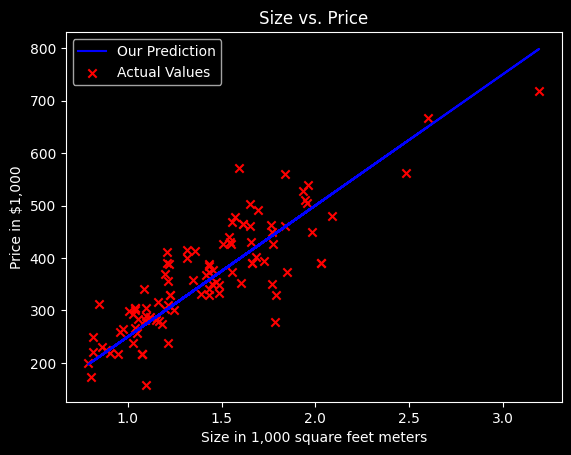

In [11]:
tmp_f_wb = compute_model_output(x_train, w, b)

# Plot our model prediction
plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')

# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

# Set the title
plt.title("Size vs. Price")
# Set the y-axis label
plt.ylabel('Price in $1,000')
# Set the x-axis label
plt.xlabel('Size in 1,000 square feet meters')
plt.legend()
plt.show()

SHAFE:JAWAD

This is the COST FUNCTION, which tells us HOW WRONG our model is. For each training example, we compute the prediction, then calculate how far off it is from the actual price. We square this error (so negatives dont cancel positives and big errors get penalized MORE). Then we average all these squared errors and divide by 2. The factor of 2 in the denominator just makes the derivative cleaner when we do gradient descent later. A LOWER cost means our model fits better.

As you can see, setting $w = 1000$ and $b = 10$ does *not* result in a line that fits our data.

Try experimenting with different values of $w$ and $b$. What should the values be for a line that fits our data?



---
SUBMIT FEEDBACK


---



---




In [12]:
feedback("session2_Exercise1", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


<a name="5"></a>
## 5 - Compute Cost

Gradient descent involves repeated steps to adjust the value of your parameter $(w,b)$ to gradually get a smaller and smaller cost $J(w,b)$.
- At each step of gradient descent, it will be helpful for you to monitor your progress by computing the cost $J(w,b)$ as $(w,b)$ gets updated.
- In this section, you will implement a function to calculate $J(w,b)$ so that you can check the progress of your gradient descent implementation.

#### Cost function
As you may recall from the lecture, for one variable, the cost function for linear regression $J(w,b)$ is defined as

$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

- You can think of $f_{w,b}(x^{(i)})$ as the model's prediction of your restaurant's profit, as opposed to $y^{(i)}$, which is the actual profit that is recorded in the data.
- $m$ is the number of training examples in the dataset

#### Model prediction

- For linear regression with one variable, the prediction of the model $f_{w,b}$ for an example $x^{(i)}$ is representented as:

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b$$

This is the equation for a line, with an intercept $b$ and a slope $w$



### Exercise 2: Cost Function

Complete the code of the `compute_cost` methdod below to:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b
    $$
   
    * The cost for that example  $$cost^{(i)} =  (f_{wb}(x^{(i)}) - y^{(i)})^2$$
    

* Return the total cost over all examples
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} cost^{(i)}$$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

SHAFE:JAWAD

**How to approach this exercise:**

We need to calculate how wrong our model is overall. The cost function does this:
1. Loop through every training example
2. For each one, compute the prediction using w*x + b
3. Subtract the actual value to get the error
4. Square the error so negatives dont cancel positives
5. Add up all squared errors
6. Divide by 2m to get the average

The output is a single number. Lower cost = better model.

In [13]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.

    Args:
        x (ndarray): Shape (m,) Input to the model (Population of cities)
        y (ndarray): Shape (m,) Label (Actual profits for the cities)
        w, b (scalar): Parameters of the model

    Returns
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    m = x.shape[0]  # SHAFE:JAWAD number of training examples

    cost_sum = 0
    for i in range(m):
        fwb_i = x[i]*w + b  # SHAFE:JAWAD prediction for house i
        cost_i = (fwb_i - y[i])**2  # SHAFE:JAWAD squared error, big errors punished more
        cost_sum = cost_sum + cost_i  # SHAFE:JAWAD accumulate total error

    total_cost = cost_sum/(2*m)  # SHAFE:JAWAD divide by 2m for mean squared error form

    return total_cost

You can check if your implementation was correct by running the following test code:

SHAFE:JAWAD

This 3D surface plot shows how the cost J changes as we vary w and b. The goal of gradient descent is to find the LOWEST point on this surface, which is where our model fits best. You can see the surface has a bowl shape, meaning there is ONE minimum we are trying to reach.

In [14]:
# Compute cost with some initial values for paramaters w, b
initial_w = 1000
initial_b = 10

cost = compute_cost(x_train, y_train, initial_w, initial_b)
print(type(cost))
print(f'Cost at initial w (zeros): {cost:.3f}')



<class 'numpy.float64'>
Cost at initial w (zeros): 620793.518


**Expected Output**:
<table>
  <tr>
    <td> <b>Cost at w=1000, b=10:<b> 620793.518 </td>
  </tr>
</table>


---
SUBMIT FEEDBACK


---



---




In [15]:
feedback("session2_Exercise2", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


SHAFE:JAWAD

This function computes the GRADIENT, which tells us which direction to move w and b to reduce the cost. Think of the gradient as a compass pointing UPHILL on the cost surface. We want to go the OPPOSITE direction (downhill) to minimize cost. For each training example, we compute how wrong our prediction is, then multiply by x for the w gradient. The gradient for b is just the error itself. We average over all examples to get the final gradient values.

In [16]:
math.sqrt(2*cost)

1114.2652449556347

### Plotting the cost function

/Users/jawadmehmoodkhanqayyum/Documents/GitHub/Semester5/course-materials/app/subjects/MI/MI-EXAM/PART2-ML-neural-networks/NOTEBOOKS-code-practice/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/jawadmehmoodkhanqayyum/Documents/GitHub/Semester5/course-materials/app/subjects/MI/MI-EXAM/PART2-ML-neural-networks/NOTEBOOKS-code-practice/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


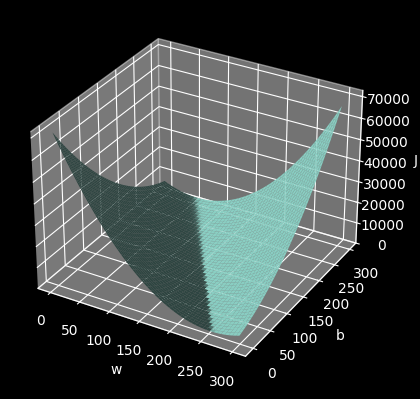

In [17]:
from mpl_toolkits.mplot3d import Axes3D
# Axes3D import has side effects, it enables using projection='3d' in add_subplot
def fun(x, y):
    return x**2 + y

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
w = b = np.arange(0, 300.0, 1)
W, B = np.meshgrid(w, b)
js = np.array(compute_cost(x_train, y_train, np.ravel(W), np.ravel(B)))
J = js.reshape(W.shape)

ax.plot_surface(W, B, J)

ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('J')

plt.show()

**Expected Output**:
<table>
  <tr>
    <td> <b>Gradient at test w=0, b=0 <b></td>
    <td> 1643.6115982424244 1065.2176565656566</td>
  </tr>
</table>

<a name="6"></a>
## 6 - Gradient descent

In this section, you will implement the gradient for parameters $w, b$ for linear regression.

As described in the lecture videos, the gradient descent algorithm is:

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & \phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; &
\newline & \rbrace\end{align*}$$

where, parameters $w, b$ are both updated simultaniously and where  
$$
\frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{2}
$$
$$
\frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)} \tag{3}
$$
* m is the number of training examples in the dataset

    
*  $f_{w,b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$, is the target value


You will implement a function called `compute_gradient` which calculates $\frac{\partial J(w)}{\partial w}$, $\frac{\partial J(w)}{\partial b}$

SHAFE:JAWAD

**How to approach this exercise:**

The gradient tells us which direction to move w and b to reduce cost. We need to:
1. Loop through all training examples
2. For each example compute the prediction error (prediction - actual)
3. For dj_dw: multiply error by x and accumulate
4. For dj_db: just accumulate the error
5. Divide both by m to get the average gradient

The result is two numbers that tell us how to update w and b.

<a name="ex03"></a>
### Exercise 3: Compute Gradient

Please complete the `compute_gradient` function to:

* Iterate over the training examples, and for each example, compute:
    * The prediction of the model for that example
    $$
    f_{wb}(x^{(i)}) =  wx^{(i)} + b
    $$
   
    * The gradient for the parameters $w, b$ from that example
        $$
        \frac{\partial J(w,b)}{\partial b}^{(i)}  =  (f_{w,b}(x^{(i)}) - y^{(i)})
        $$
        $$
        \frac{\partial J(w,b)}{\partial w}^{(i)}  =  (f_{w,b}(x^{(i)}) -y^{(i)})x^{(i)}
        $$
    

* Return the total gradient update from all the examples
    $$
    \frac{\partial J(w,b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial b}^{(i)}
    $$
    
    $$
    \frac{\partial J(w,b)}{\partial w}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} \frac{\partial J(w,b)}{\partial w}^{(i)}
    $$
  * Here, $m$ is the number of training examples and $\sum$ is the summation operator

If you get stuck, you can check out the hints presented after the cell below to help you with the implementation.

In [18]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression
    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): target values
      w,b (scalar)    : model parameters
    Returns
      dj_dw (scalar): The gradient of the cost w.r.t. the parameters w
      dj_db (scalar): The gradient of the cost w.r.t. the parameter b
     """

    m = x.shape[0]  # SHAFE:JAWAD number of training examples
    dj_dw = 0  # SHAFE:JAWAD will accumulate gradient for w
    dj_db = 0  # SHAFE:JAWAD will accumulate gradient for b

    for i in range(m):
      f_wb_i = x[i]*w + b  # SHAFE:JAWAD get prediction for example i
      error = f_wb_i - y[i]  # SHAFE:JAWAD how wrong is our prediction
      dj_dw += error * x[i]  # SHAFE:JAWAD gradient for w includes x term
      dj_db += error  # SHAFE:JAWAD gradient for b is just the error

    dj_dw = dj_dw / m  # SHAFE:JAWAD average over all examples
    dj_db = dj_db / m
    return dj_dw, dj_db

SHAFE:JAWAD

This is the main GRADIENT DESCENT algorithm that puts everything together. It starts with initial values for w and b, then repeatedly:
1. Computes the gradient (which way is downhill)
2. Takes a small step in that direction by subtracting alpha times the gradient

The learning rate alpha controls how big each step is. Too big and we might overshoot the minimum, too small and it takes forever. We run this for num_iters iterations, and at each step we save the cost so we can plot how it decreases over time.

Run the cells below to check your implementation of the `compute_gradient` function with two different initializations of the parameters $w$,$b$.

SHAFE:JAWAD

Now we run gradient descent with our chosen hyperparameters. We start w and b at 0, use a learning rate of 0.01, and run for 10000 iterations. The printout shows how the cost decreases over time, proving our algorithm is working. The final w and b values are what we will use for predictions.

In [19]:
# Compute and display gradient with w initialized to zeroes
initial_w = 0
initial_b = 0

tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)
print('Gradient at initial w, b (zeros):', tmp_dj_dw, tmp_dj_db)

Gradient at initial w, b (zeros): -551.7836239797983 -363.1560808080808


Now let's run the gradient descent algorithm implemented above on our dataset.

**Expected Output**:
<table>
  <tr>
    <td> <b>Gradient at  w=0, b=0 <b></td>
    <td> -551.7836239797981 -363.1560808080808</td>
  </tr>
</table>

In [20]:
# Compute and display cost and gradient with non-zero w
test_w = 1000
test_b = 10
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

print('Gradient at test w, b:', tmp_dj_dw, tmp_dj_db)

Gradient at test w, b: 1643.6115982424237 1065.2176565656566


**Expected Output**:
<table>
  <tr>
    <td> <b>Gradient at test w=1000, b=10 <b></td>
    <td> 1643.6115982424244 1065.2176565656566</td>
  </tr>
</table>

SHAFE:JAWAD

This animation shows how the prediction line evolves as gradient descent runs. At first the line might be way off, but with each iteration it rotates and shifts to better fit the data. This is a nice way to visualize WHAT gradient descent is actually doing, finding the line that best matches our training data.


---
SUBMIT FEEDBACK


---



---




In [21]:
feedback("session2_Exercise3", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


SHAFE:JAWAD

**How to approach this exercise:**

This is where we put it all together. Gradient descent runs in a loop:
1. Compute the gradient using the gradient function
2. Update w by subtracting alpha * dj_dw
3. Update b by subtracting alpha * dj_db
4. Track the cost at each step to make sure its going down

We run this for num_iters times. The learning rate alpha controls step size. If cost decreases smoothly we are on the right track.

SHAFE:JAWAD

Now we use our trained model to make predictions. We call compute_model_output with the optimal w and b values we found from gradient descent. This gives us a predicted price for every house in our training set.

<a name="ex04"></a>
### Exercise 4:  Updating Equation Gradient Descent


You will now find the optimal parameters of a linear regression model by using batch gradient descent. Recall batch refers to running all the examples in one iteration.

- **TASK**: Implement the updating equation of gradient descent

$$\begin{align*}&
\phantom {0000} b := b -  \alpha \frac{\partial J(w,b)}{\partial b} \newline       \; & \phantom {0000} w := w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{1}  \; &
\newline & \end{align*}$$



- A good way to verify that gradient descent is working correctly is to look
at the value of $J(w,b)$ and check that it is decreasing with each step.

- Assuming you have implemented the gradient and computed the cost correctly and you have an appropriate value for the learning rate alpha, $J(w,b)$ should never increase and should converge to a steady value by the end of the algorithm.

In [22]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking
    num_iters gradient steps with learning rate alpha

    Args:
      x :    (ndarray): Shape (m,)
      y :    (ndarray): Shape (m,)
      w_in, b_in : (scalar) Initial values of parameters of the model
      cost_function: function to compute cost
      gradient_function: function to compute the gradient
      alpha : (float) Learning rate
      num_iters : (int) number of iterations to run gradient descent
    Returns
      w : (ndarray): Shape (1,) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """

    m = len(x)

    # SHAFE:JAWAD these lists track the learning progress for visualization
    J_history = []
    w_history = [w_in]
    b_history = [b_in]
    w = copy.deepcopy(w_in)  # SHAFE:JAWAD avoid modifying original
    b = b_in

    for i in range(num_iters):

        # SHAFE:JAWAD compute gradient, tells us which direction to move
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # SHAFE:JAWAD update step: move opposite to gradient direction, scaled by alpha
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        # SHAFE:JAWAD save cost to track if we are improving
        if i<100000:
            cost = cost_function(x, y, w, b)
            J_history.append(cost)

        # SHAFE:JAWAD print progress every 10% of iterations
        if i% math.ceil(num_iters/10) == 0:
            w_history.append(w)
            b_history.append(b)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w, b, J_history, w_history, b_history

Now let's run the gradient descent algorithm above to learn the parameters for our dataset.

SHAFE:JAWAD

Here we use our model to predict prices for NEW houses. For a 1000 sqft house we plug in x=1 (since we scaled by 1000), and for a 2000 sqft house we plug in x=2. Then we multiply by 1000 to convert back to dollars. This shows the REAL VALUE of training a model, we can now estimate prices for houses we have never seen before.

Iteration    0: Cost 67073.97   
Iteration 1000: Cost  1504.39   
Iteration 2000: Cost  1471.59   
Iteration 3000: Cost  1460.50   
Iteration 4000: Cost  1456.75   
Iteration 5000: Cost  1455.48   
Iteration 6000: Cost  1455.05   
Iteration 7000: Cost  1454.91   
Iteration 8000: Cost  1454.86   
Iteration 9000: Cost  1454.84   
w,b found by gradient descent: 216.3873236706632 56.2526725869892


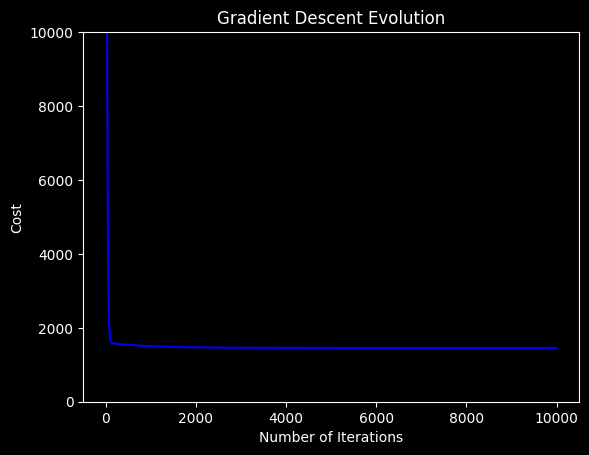

In [23]:
# initialize fitting parameters. Recall that the shape of w is (n,)
initial_w = 0.
initial_b = 0.

# some gradient descent settings
iterations = 10000
alpha = 0.01

w_optimal,b_optimal,J_history, w_history, b_history = gradient_descent(x_train ,y_train, initial_w, initial_b,
                     compute_cost, compute_gradient, alpha, iterations)


print("w,b found by gradient descent:", w_optimal, b_optimal)

# Set the title
plt.title("Gradient Descent Evolution")
# Set the y-axis label
plt.ylabel('Cost')
plt.ylim(0,10000)
# Set the x-axis label
plt.xlabel('Number of Iterations')

#plt.ylim(4,10)

# Plot the linear fit
plt.plot(np.arange(0,iterations,1), J_history, c = "b")




**Expected Output**:
<table>
  <tr>
    <td> <b> w, b found by gradient descent after 10000 iterations with alpha = 0.01<b></td>
    <td> 216.3873236706632 56.2526725869892</td>
  </tr>
</table>


---
SUBMIT FEEDBACK


---



---




In [24]:
feedback("session2_Exercise4", finished=True, understood=True, comment="No comments")

FEEDBACK SUBMITTED. THANKS!!! :D


### Inspecting behaviour of Gradient Descent

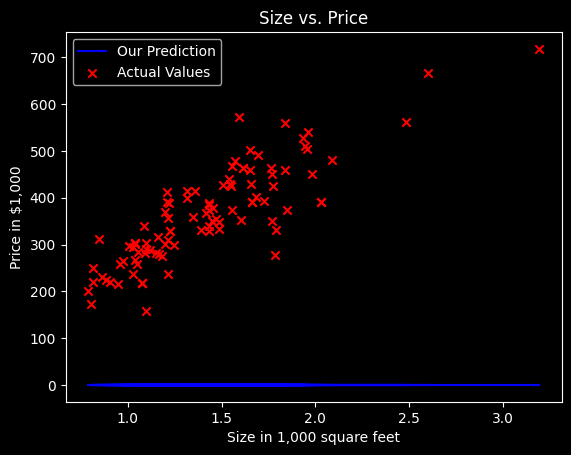

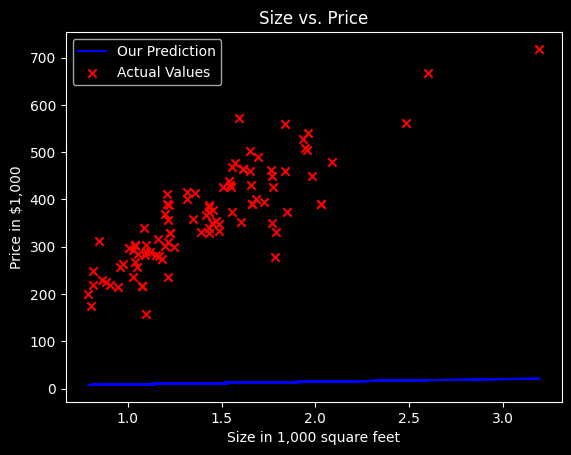

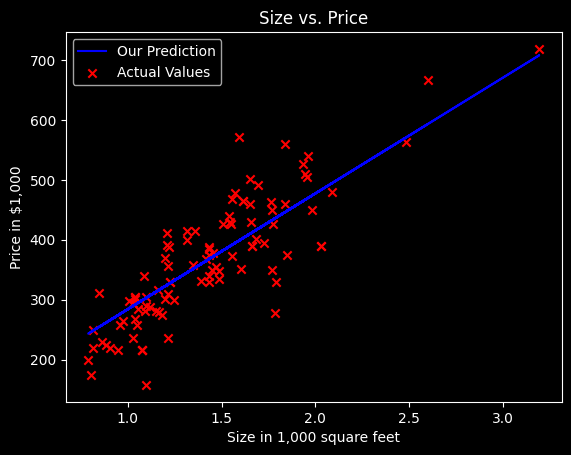

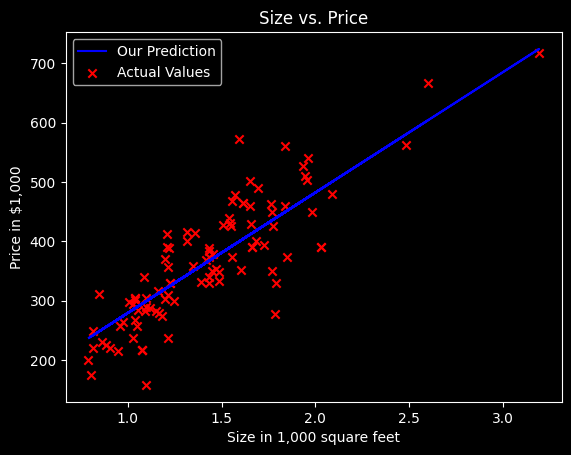

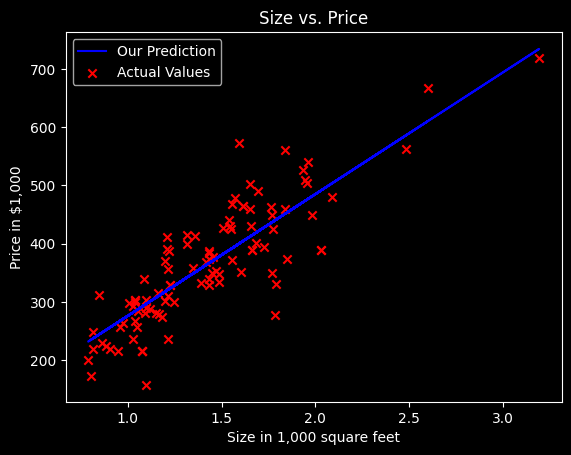

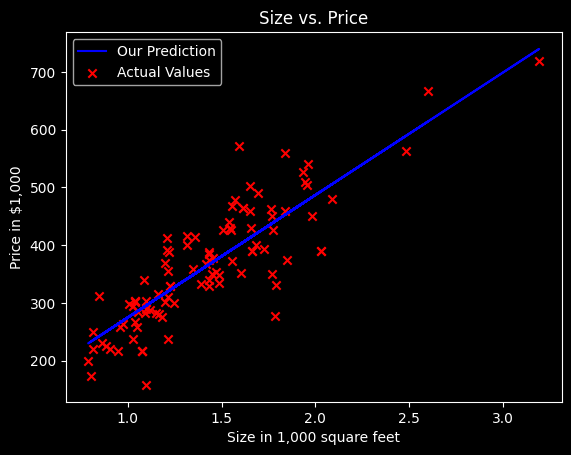

In [ ]:
for (w_t, b_t) in zip(w_history, b_history):
  tmp_f_wb = compute_model_output(x_train, w_t, b_t)

  # Plot our model prediction
  plt.plot(x_train, tmp_f_wb, c='b',label='Our Prediction')

  # Plot the data points
  plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')

  # Set the title
  plt.title("Size vs. Price")
  # Set the y-axis label
  plt.ylabel('Price in $1,000')
  # Set the x-axis label
  plt.xlabel('Size in 1,000 square feet')
  plt.legend()
  plt.show(block=False)
  plt.pause(1)


### Making Predictions

We will now use the final parameters from gradient descent to plot the linear fit.

Recall that we can get the prediction for a single example $f(x^{(i)})= wx^{(i)}+b$.

To calculate the predictions on the entire dataset, we can loop through all the training examples and calculate the prediction for each example. This is shown in the code block below.

In [ ]:
predicted = compute_model_output(x_train, w_optimal, b_optimal)

We will now plot the predicted values to see the linear fit.

In [ ]:
# Plot the linear fit
plt.plot(x_train, predicted, c = "b",label='Our Prediction')

# Create a scatter plot of the data.
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')

# Set the title
plt.title("Size vs. Price")
# Set the y-axis label
plt.ylabel('Price in $1,000')
# Set the x-axis label
plt.xlabel('Size in 1,000 square feet')
plt.legend()
plt.show()


SHAFE:JAWAD
WHAT WE HAVE LEARNED

1. Linear regression predicts a continuous output by fitting a straight line through data points using the equation y = wx + b where w is the weight and b is the bias.

2. The COST FUNCTION measures how wrong our predictions are. We use Mean Squared Error which squares the differences between predicted and actual values then averages them.

3. GRADIENT DESCENT is the optimization algorithm that finds the best w and b by repeatedly updating them in the direction that reduces the cost most.

4. The LEARNING RATE alpha controls how big each update step is. Too large causes overshooting and divergence. Too small means painfully slow convergence.

5. We compute PARTIAL DERIVATIVES of the cost with respect to w and b separately. These tell us which direction to move each parameter.

6. The cost should DECREASE with each iteration. If it goes up or oscillates wildly something is wrong with your learning rate or code.

7. FEATURE SCALING normalizes input values to similar ranges which helps gradient descent converge much faster and more reliably.

In [ ]:
predict1 = 1 * w_optimal + b_optimal
print('For area = 1,000 we predict a price of $%.0f' % (predict1*1000))

predict2 = 2 * w_optimal + b_optimal
print('For area = 2,000 we predict a price of $%.0f' % (predict2*1000))

**Expected Output**:
<table>
  <tr>
    <td> <b> For area = 1,000, we predict a selling price of<b></td>
    <td> $272,640 </td>
  </tr>
  
  <tr>
    <td> <b> For area = 2,000, we predict a selling price of<b></td>
    <td> $489,027</td>
  </tr>
</table>

SHAFE:JAWAD
WHAT WE HAVE LEARNED

1. Linear regression predicts a continuous output by fitting a straight line through data points using the equation y = wx + b where w is the weight and b is the bias.

2. The COST FUNCTION measures how wrong our predictions are. We use Mean Squared Error which squares the differences between predicted and actual values then averages them.

3. GRADIENT DESCENT is the optimization algorithm that finds the best w and b by repeatedly updating them in the direction that reduces the cost most.

4. The LEARNING RATE alpha controls how big each update step is. Too large causes overshooting and divergence. Too small means painfully slow convergence.

5. We compute PARTIAL DERIVATIVES of the cost with respect to w and b separately. These tell us which direction to move each parameter.

6. The cost should DECREASE with each iteration. If it goes up or oscillates wildly something is wrong with your learning rate or code.

7. FEATURE SCALING normalizes input values to similar ranges which helps gradient descent converge much faster and more reliably.